In [62]:
from IPython.core.pylabtools import figsize
# Access reviews and information from Google play application
from google_play_scraper import app, reviews, Sort, reviews_all
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from wordcloud import WordCloud  # Visualization word as word cloud

# Download NLTK library if not yet
# import nltk
# nltk.download("punkt")
# nltk.download("punkt_tab")
# nltk.download("stopwords")

np.random.seed(42)  # Set random seed
pd.options.mode.chained_assignment = None  # Disable chaining warning

### Scraping dataset with Google play Scrapper

In [63]:
scrap_review = reviews_all(
    "com.miHoYo.GenshinImpact",     # Application ID
    lang="id",                      # Reviews language (default: 'en')
    country="id",                   # From Country (default: 'us')
    sort=Sort.MOST_RELEVANT,        # Sort reviews by (default: Sort.MOST_RELEVANT)
    count=2000                      # Maximum reviews to take
)

### Save all reviews to csv

In [64]:
import csv

datasets_path = "./datasets/genshin_impact_application_reviews.csv"

with open(datasets_path, mode="w", newline='', encoding="utf-8") as file:
    writer = csv.writer(file)
    writer.writerow(["Reviews"])  # Write header column

    for review in scrap_review:
        writer.writerow([review["content"]])  # Write review content in csv file

### Loading Dataset

In [65]:
df = pd.DataFrame(scrap_review)
df.to_csv("./datasets/genshin_impact_application_reviews_full.csv")

# Make Dataframe from scrap_review result
df = pd.DataFrame(scrap_review)

# See length datasets
print(f"Shape datasets: {df.shape}")

# See 5 sample dataset
df.head()

Shape datasets: (45000, 11)


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,1af7167f-f8ad-4c4f-a6b1-9b84d26cb939,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Visual cukup memanjakan mata, salah satu game ...",5,57,5.4.0_30057195_30231699,2025-02-12 07:39:48,None,NaT,5.4.0_30057195_30231699
1,f3c3d00d-2902-439a-ac07-689b0accd777,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Sebenernya ini adalah game yang bagus, Lore ny...",5,22,5.4.0_30057195_30231699,2025-02-13 13:54:29,None,NaT,5.4.0_30057195_30231699
2,943c249a-366a-4d12-897c-61f9a5f835bd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,semua yg berkembang dari 4.0 hingga sekarang s...,5,6,5.4.0_30057195_30231699,2025-02-12 10:16:33,None,NaT,5.4.0_30057195_30231699
3,74d78d7c-74c6-4852-a2d3-aaa8267e1c79,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,banyak yang rating rendah soal obrolan yg berk...,5,55,5.4.0_30057195_30231699,2025-02-12 11:51:20,None,NaT,5.4.0_30057195_30231699
4,5871a4a1-11c2-4469-9cea-78d96bdf18f9,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Gamenya sudah bagus tapi kadang pas lagi main ...,1,62,5.4.0_30057195_30231699,2025-02-15 07:11:12,None,NaT,5.4.0_30057195_30231699


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              45000 non-null  object        
 1   userName              45000 non-null  object        
 2   userImage             45000 non-null  object        
 3   content               45000 non-null  object        
 4   score                 45000 non-null  int64         
 5   thumbsUpCount         45000 non-null  int64         
 6   reviewCreatedVersion  30201 non-null  object        
 7   at                    45000 non-null  datetime64[ns]
 8   replyContent          3754 non-null   object        
 9   repliedAt             3754 non-null   datetime64[ns]
 10  appVersion            30201 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 3.8+ MB


### Cleaning Data

In [67]:
# Drop Duplicate col
clean_df = df.drop_duplicates()
clean_df = df.dropna()

print(f"Shape datasets after clean: {clean_df.shape}")

Shape datasets after clean: (2223, 11)


### Processing Text

In [68]:
def simple_cleaning_text(text: str) -> str:
    text = re.sub(r"@[A-Za-z0-9]+", "", text)   # Remove mention @
    text = re.sub(r"#[A-Za-z0-9]+", "", text)   # Remove hashtag #
    text = re.sub(r"https\S+", "", text)        # Remove link http/s
    text = re.sub(r"[0-9]+", "", text)  # Remove number
    text = re.sub(f"[^\w\s]", "", text)  # Remove besides number and char

    text = text.replace("\n", " ")  # Enter into space
    text = text.translate(str.maketrans("", "", string.punctuation))  # Remove punctuation
    text = text.strip(" ")  # Remove start and end space

    return text


def case_folding_text(text: str) -> str:
    return text.lower()


def tokenization_text(text: str) -> str:
    tokens = word_tokenize(text)
    return tokens


def filtering_text(text: str) -> list[str]:
    # Initialization list stopword indonesian and english
    list_stop_word = set(stopwords.words("indonesian"))
    list_stop_word_en = set(stopwords.words("english"))

    # Merge stopword indonesian and english
    list_stop_word.update(list_stop_word_en)
    # Add some slang in indonesian language
    list_stop_word.update(
        ["njir", "bjir", "lah", "kan", "iyaa", "ga", "loh", "kan", "ya", "yaa", "iyaa", "gaa", "cuy", "cuuy", "woy","woi"]
    )

    # Filtered text
    filtered = []
    for txt in text:
        if txt not in list_stop_word:
            filtered.append(txt)

    text = filtered
    return text


def stemming_text(text: str)-> str:
    # Initializing Stemmer
    factory = StemmerFactory()
    stemmer  = factory.create_stemmer()

    # Make word to list
    words = text.split()

    # Stemming each word
    stemmed_word = [stemmer.stem(word) for word in words]

    # Join words again
    stemmed_text = ' '.join(stemmed_word)
    return stemmed_text

def to_sentence(list_word)-> str:
    sentence = " ".join([word for word in list_word])
    return sentence

### Remove kata slang

In [69]:
slang_words =  {
    "p2w": "bayar untuk menang",
    "pay to win": "bayar untuk menang",
    "rateup": "naik",
    "whale": "kaya",
    "f2p": "gratis",
    "primogem": "uang",
    "primo": "uang",
    "resin": "energi",
    "banner": "event",
    "meta": "kuat",
    "dps": "damage",
    "support": "dukung",
    "abyss": "tantang",
    "sultan": "kaya",
    "boobasword": "pedang",
    "luck": "untung",
    "cuan": "untung",
    "beban": "guna",
    "mondstadt": "kota",
    "build": "rakit",
    "resinbocor": "buang",
    "nerf": "lemah",
    "event": "acara",
    "op": "kuat",
    "artefak": "barang langka",
    "bangkrut": "habis",
    "maks": "maksimal",
    "bgt": "banget",
    "masi": "masih",
    "abis": "habis"
}

def fix_slang_word(text: str)-> str:
    words = text.split()
    filtered_text = []

    for word in words:
        if word.lower() in slang_words:
            filtered_text.append(slang_words[word.lower()])
        else:
            filtered_text.append(word)

    clean_text = " ".join(filtered_text)
    return clean_text

### Implements function

In [70]:
# Clean 'content' text and make new column 'simple_clean_text' from simple_cleaning_text function
clean_df["simple_clean_text"] = clean_df["content"].apply(simple_cleaning_text)

clean_df["case_folding_text"] = clean_df["simple_clean_text"].apply(case_folding_text)

clean_df["fixed_slang_word"] = clean_df["case_folding_text"].apply(fix_slang_word)

clean_df["tokenized_text"] = clean_df["fixed_slang_word"].apply(tokenization_text)

clean_df["stopwords_text"] = clean_df["tokenized_text"].apply(filtering_text)

clean_df["clean_text"] = clean_df["stopwords_text"].apply(to_sentence)

# IDK stemmed text is so long
# clean_df["stemmed_text"] = clean_df["clean_text"].apply(stemming_text)

clean_df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion,simple_clean_text,case_folding_text,fixed_slang_word,tokenized_text,stopwords_text,clean_text
25,5377d8b9-5f3d-4a27-9e96-0a4983ac44cd,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Kurangi dialog obrolan yang berkepanjangan dan...,1,1962,5.3.0_29183395_29332470,2025-01-07 00:06:07,Terima kasih atas dukungan Traveler terhadap G...,2025-02-19 17:41:08,5.3.0_29183395_29332470,Kurangi dialog obrolan yang berkepanjangan dan...,kurangi dialog obrolan yang berkepanjangan dan...,kurangi dialog obrolan yang berkepanjangan dan...,"[kurangi, dialog, obrolan, yang, berkepanjanga...","[kurangi, dialog, obrolan, berkepanjangan, fit...",kurangi dialog obrolan berkepanjangan fitur sk...
47,f39a92d4-ee83-4119-b196-567282dfcecc,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Untuk event, terlalu banyak dialog tidak penti...",1,93,5.3.0_29183395_29332470,2025-01-21 17:25:57,Terima kasih atas dukungan Traveler terhadap G...,2025-02-18 17:51:02,5.3.0_29183395_29332470,Untuk event terlalu banyak dialog tidak pentin...,untuk event terlalu banyak dialog tidak pentin...,untuk acara terlalu banyak dialog tidak pentin...,"[untuk, acara, terlalu, banyak, dialog, tidak,...","[acara, dialog, skip, males, bermain, memencat...",acara dialog skip males bermain memencat space...
59,faa55d6f-fae9-40a8-a87f-0ee8bb638036,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,gue saranin sih buat yang mau main game petual...,1,69,5.3.0_29183395_29332470,2025-01-22 23:58:00,Kami mohon maaf atas ketidaknyamanan yang Anda...,2025-02-18 17:46:28,5.3.0_29183395_29332470,gue saranin sih buat yang mau main game petual...,gue saranin sih buat yang mau main game petual...,gue saranin sih buat yang mau main game petual...,"[gue, saranin, sih, buat, yang, mau, main, gam...","[gue, saranin, sih, main, game, petualangan, p...",gue saranin sih main game petualangan penuh ak...
67,b915791b-a565-4fb7-b2d8-a6c1568c8140,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Woy kasih skip story skip skip skip skip. Di k...,1,49,5.3.0_29183395_29332470,2025-01-20 00:47:34,Terima kasih atas dukungan Traveler terhadap G...,2025-02-18 17:29:29,5.3.0_29183395_29332470,Woy kasih skip story skip skip skip skip Di ki...,woy kasih skip story skip skip skip skip di ki...,woy kasih skip story skip skip skip skip di ki...,"[woy, kasih, skip, story, skip, skip, skip, sk...","[kasih, skip, story, skip, skip, skip, skip, l...",kasih skip story skip skip skip skip lu pade k...
68,79fc4283-dbf1-4795-b2d2-c231dd287172,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"fitur skip di buat lah,cerita yang tidak terla...",1,34,5.3.0_29183395_29332470,2025-01-04 01:43:51,Terima kasih atas dukungan Traveler terhadap G...,2025-02-18 18:05:39,5.3.0_29183395_29332470,fitur skip di buat lahcerita yang tidak terlal...,fitur skip di buat lahcerita yang tidak terlal...,fitur skip di buat lahcerita yang tidak terlal...,"[fitur, skip, di, buat, lahcerita, yang, tidak...","[fitur, skip, lahcerita, kisah, karakter, npc,...",fitur skip lahcerita kisah karakter npc karakt...


### Labeling negative and positive text

In [71]:
from io import StringIO
import requests

lexicon_positive = dict()

lexicon_positive_response = requests.get("https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_positive.csv")

if lexicon_positive_response.status_code == 200:
    # Read csv context
    reader = csv.reader(StringIO(lexicon_positive_response.text), delimiter=",")

    for row in reader:
        lexicon_positive[row[0]] = int(row[1])
        # insert to dictionary 'name': <word_value>
else:
    print("Failed to fetch lexicon positive!!!")


lexicon_negative = dict()

lexicon_negative_response = requests.get("https://raw.githubusercontent.com/angelmetanosaa/dataset/main/lexicon_negative.csv")

if lexicon_negative_response.status_code == 200:
    reader = csv.reader(StringIO(lexicon_negative_response.text), delimiter=",")

    for row in reader:
        lexicon_negative[row[0]] = int(row[1])
else:
    print("Failed to fetch lexicon negative!!!")

Make function to determine sentiment polarity from tweet

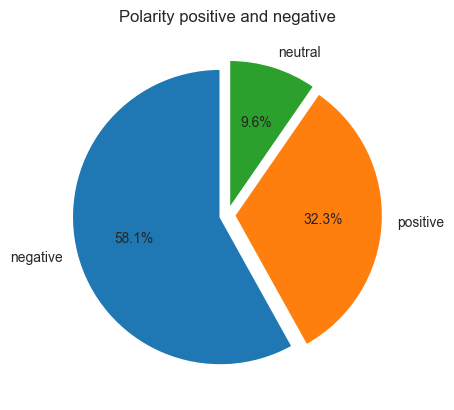

In [72]:
def sentiment_analysis_lexicon_indonesian(text: str):
    # initialization sentiment score
    score = 0

    # Scoring negative word
    for word in text:
        if word in lexicon_positive:
            score = score + lexicon_positive[word]
            # Add score if there is a positive word

    for word in text:
        if word in lexicon_negative:
            score = score + lexicon_negative[word]
            # Add score if there is a negative word

    # initialization
    polarity = ''

    if score >= 1:
        polarity = "positive"
    elif score <= -1:
        polarity = "negative"
    else:
        polarity = "neutral"

    return polarity, score


# Implement sentiment_analysis_lexicon_indonesian function

results = clean_df["stopwords_text"].apply(sentiment_analysis_lexicon_indonesian)
results = list(zip(*results))

clean_df["polarity"] = results[0]
clean_df["polarity_score"] = results[1]

data = clean_df["polarity"].value_counts()
plt.pie(list(data.values), labels=list(data.keys()), explode=[0.05, 0.05, 0.05], autopct="%1.1f%%", startangle=90)
plt.title("Polarity positive and negative")
plt.show()

In [73]:
def get_polarity_text(df, type):
    indices = df[df["polarity"] == type].index
    text = df.loc[indices, 'clean_text'].tolist()

    return ' '.join(text)

positive_text = get_polarity_text(clean_df, "positive")
neutral_text = get_polarity_text(clean_df, "neutral")
negative_text = get_polarity_text(clean_df, "negative")

__Visualization to WorldCloud__

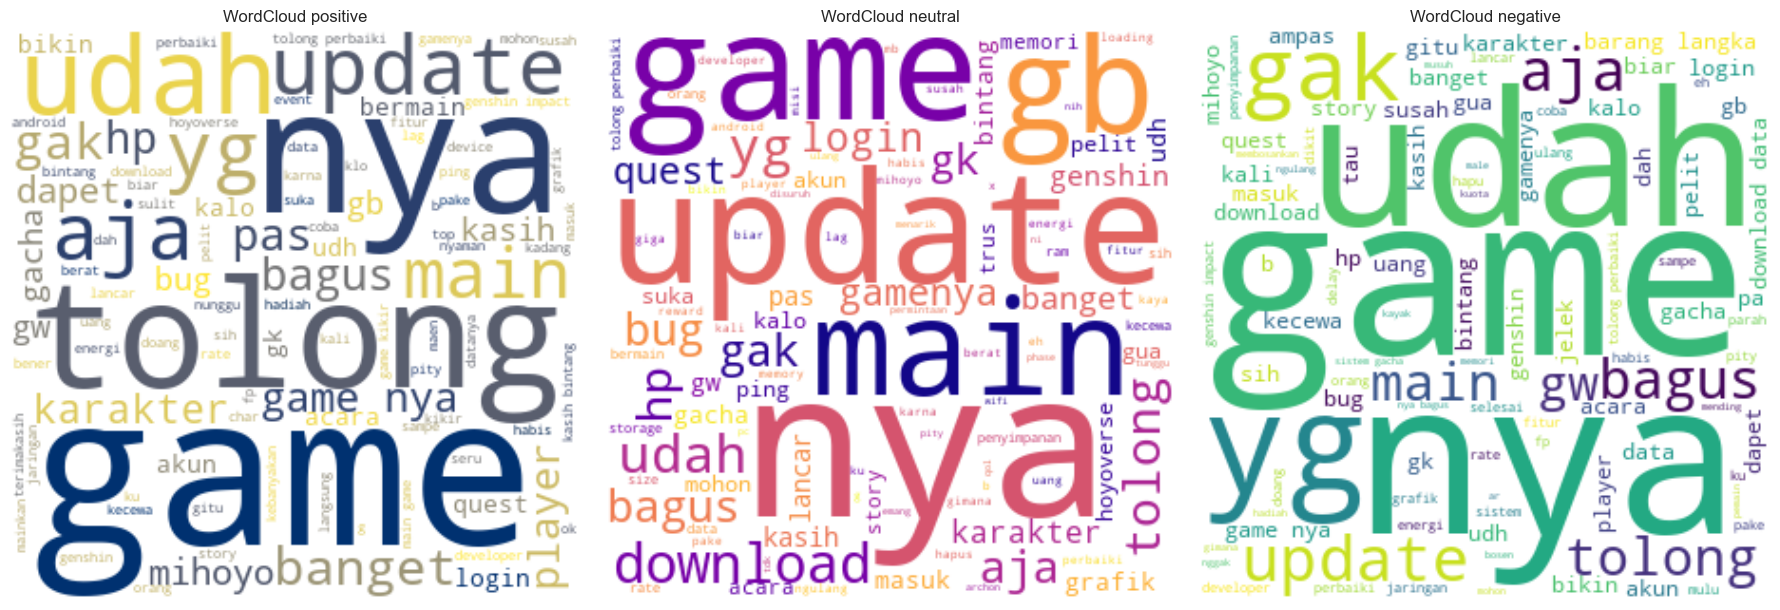

In [74]:
wc_positive = WordCloud(width=300, height=300, background_color="white", colormap="cividis", max_words=100).generate(positive_text)
wc_neutral = WordCloud(width=300, height=300, background_color="white", colormap="plasma", max_words=100).generate(neutral_text)
wc_negative = WordCloud(width=300, height=300, background_color="white", colormap="viridis", max_words=100).generate(negative_text)

# Make layout 1 row and 3 col
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(wc_positive, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("WordCloud positive")

axes[1].imshow(wc_neutral, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("WordCloud neutral")

axes[2].imshow(wc_negative, interpolation="bilinear")
axes[2].axis("off")
axes[2].set_title("WordCloud negative")

plt.tight_layout()
plt.show()

### Data Splitting dan Extraction with TF-IDF

In [75]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split

# Split into feature (tweet) and label (sentiment)
X = clean_df["clean_text"]
y = clean_df["polarity"]

# Extraction feature
tfidf = TfidfVectorizer(max_features=250, max_df=0.85, min_df=20)
X_tfidf = tfidf.fit_transform(X)

# Convert extraction features results into Dataframe
feature_df = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Split into test and train
X_train, X_test, y_train, y_test = train_test_split(X_tfidf, y, test_size=0.2, random_state=42)

# See feature dataframe
feature_df

,acara,aja,akun,ama,ampas,android,aneh,anniversary,aplikasi,ar,...,udh,ukuran,ulang,unduh,uninstall,update,versi,wifi,yah,yg
0,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.093025,0.0,0.0,0.0,0.0
1,0.47349,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
3,0.00000,0.095191,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
4,0.00000,0.212990,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2218,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2219,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2220,0.00000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0
2221,0.49659,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0


### Modeling
__Naive Bayes__

In [76]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.metrics import accuracy_score

# initialization modeled
naive_bayes = BernoulliNB()

# Train model

naive_bayes.fit(X_train.toarray(), y_train)

# Prediction sentiment in train data and test data
y_pred_train_nb = naive_bayes.predict(X_train.toarray())
y_pred_test_nb = naive_bayes.predict(X_test.toarray())


# Evaluate model accuracy
accuracy_train_nb = accuracy_score(y_pred_train_nb, y_train)
accuracy_test_nb = accuracy_score(y_pred_test_nb, y_test)

print("Naive bayes model accuray")
print(f"Train accuracy: {accuracy_train_nb}")
print(f"Test accuracy: {accuracy_test_nb}")

Naive bayes model accuray
Train accuracy: 0.7452193475815523
Test accuracy: 0.6449438202247191


__Random Forest__

In [77]:
from sklearn.ensemble import RandomForestClassifier

# initialization model
random_forest = RandomForestClassifier()

# Training model
random_forest.fit(X_train.toarray(), y_train)

# Predict
y_pred_train_rf = random_forest.predict(X_train.toarray())
y_pred_test_rf = random_forest.predict(X_test.toarray())

# Evaluate model
accuracy_train_rf = accuracy_score(y_pred_train_rf, y_train)
accuracy_test_rf = accuracy_score(y_pred_test_rf, y_test)

print("Random Forest Classifier model")
print(f"Train accuracy: {accuracy_train_rf}")
print(f"Test accuracy: {accuracy_test_rf}")

Random Forest Classifier model
Train accuracy: 0.9949381327334084
Test accuracy: 0.6808988764044944


__Logistic Regression__

In [78]:
from sklearn.linear_model import LogisticRegression

# Init
logistic_regression = LogisticRegression()

# Train
logistic_regression.fit(X_train.toarray(), y_train)

# Predict
y_pred_train_lr = logistic_regression.predict(X_train.toarray())
y_pred_test_lr = logistic_regression.predict(X_test.toarray())

# Evaluate
accuracy_train_lr = accuracy_score(y_pred_train_lr, y_train)
accuracy_test_lr = accuracy_score(y_pred_test_lr, y_test)

print("Logistic Regression model")
print(f"Train accuracy: {accuracy_train_lr}")
print(f"Test accuracy: {accuracy_test_lr}")

Logistic Regression model
Train accuracy: 0.78177727784027
Test accuracy: 0.7213483146067415


__Decision Tree__

In [79]:
from sklearn.tree import DecisionTreeClassifier

# Init
decision_tree = DecisionTreeClassifier()

# Train model
decision_tree.fit(X_train.toarray(), y_train)

# Predict
y_pred_train_dt = decision_tree.predict(X_train.toarray())
y_pred_test_dt = decision_tree.predict(X_test.toarray())

# Evaluate model
accuracy_train_dt = accuracy_score(y_pred_train_dt, y_train)
accuracy_test_dt = accuracy_score(y_pred_test_dt, y_test)

print("Decision Tree model")
print(f"Train accuracy: {accuracy_train_dt}")
print(f"Test accuracy: {accuracy_test_dt}")

Decision Tree model
Train accuracy: 0.9949381327334084
Test accuracy: 0.5932584269662922


### Try to predict

In [82]:
sample_text = "Visual cukup memanjakan mata, salah satu game open world dengan penulisan story yang sangat baik, soundtrack dan BGM gamenya juga enak enak didenger, desain karakter bagus bagus meski kalo desain mungkin adiknya yang turn base masih lebih bagus, pokoknya top lah."

# Cleaning Textt
def cleaning_sample_text(text: str)-> str:
    basic_clean = simple_cleaning_text(text)
    case_folding = case_folding_text(basic_clean)
    fix_slang = fix_slang_word(case_folding)
    tokenized = tokenization_text(fix_slang)
    stopwords = filtering_text(tokenized)
    clean_text = to_sentence(stopwords)
    stemmed_text = stemming_text(clean_text)

    return stemmed_text

clean_sample_text = cleaning_sample_text(sample_text)
print(f"Sample Text cleaned: {clean_sample_text}\n")

# Feature Extraction
sample_extract = tfidf.transform([clean_sample_text])

# Predict
nb_pred = naive_bayes.predict(sample_extract)
rf_pred = random_forest.predict(sample_extract)
lr_pred = logistic_regression.predict(sample_extract)
dt_pred = decision_tree.predict(sample_extract)

print(f"Naive Bayes:        {nb_pred[0]}")
print(f"Random Forest:      {rf_pred[0]}")
print(f"Linear Regression:  {lr_pred[0]}")
print(f"Decision Tree:      {dt_pred[0]}")

Sample Text cleaned: visual manja mata salah game open world tulis story soundtrack bgm gamenya enak enak didenger desain karakter bagus bagus kalo desain adik turn base bagus pokok top

Naive Bayes:        positive
Random Forest:      negative
Linear Regression:  negative
Decision Tree:      positive
